<a href="https://colab.research.google.com/github/demsaid400-cpu/DI-BOOTCAMP/blob/main/Week4/Day4/Exercices_Structure.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Air Traffic Data Analysis - Student Exercise
## Inferential Statistics and Regression Analysis

**Student Template - Complete the TODO sections**

In this exercise, you will analyze air traffic data using inferential statistics and regression techniques. Follow the instructions and complete each section marked with `#TODO`.

### Dataset Description:
- **Dom_Pax**: Domestic Air Travel Passengers
- **Int_Pax**: International Air Travel Passengers  
- **Pax**: Total Air Travel Passengers
- **Dom_Flt**: Number of Flights (Domestic)
- **Int_Flt**: Number of Flights (International)
- **Flt**: Number of Flights (Total)
- **Dom_RPM**: Revenue Passenger-miles (Domestic)

## 1. Setup and Data Loading

In [26]:
# TODO: Import necessary libraries
# Hint: You'll need pandas, numpy, matplotlib, seaborn, scipy.stats, and sklearn modules
# Import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
# From scipy import stats
# From sklearn.model_selection import train_test_split
# From sklearn.linear_model import LinearRegression
# From sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
# From sklearn.preprocessing import StandardScaler

# Your code here:


# Set up plotting style (optional)
plt.style.use('default')
sns.set_palette("husl")

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler

# TODO: Load the dataset
# Hint: Use pd.read_csv() to load 'air_traffic_data.csv'
# If the file doesn't exist, the code below will create sample data for you

try:
    # Your code to load the dataset:
    df = pd.read_csv('air_traffic_data.csv')
    print("Dataset loaded successfully!")
    print(f"Shape: {df.shape}")
except FileNotFoundError:
    print("Creating sample air traffic data...")
    import numpy as np
    import pandas as pd

    # Create sample data
    np.random.seed(42)
    n_samples = 200

    # Generate correlated data
    dom_flights = np.random.normal(15000, 3000, n_samples)
    int_flights = np.random.normal(8000, 2000, n_samples)

    dom_pax = dom_flights * np.random.normal(12, 2, n_samples) + np.random.normal(0, 10000, n_samples)
    int_pax = int_flights * np.random.normal(15, 3, n_samples) + np.random.normal(0, 15000, n_samples)

    dom_rpm = dom_pax * np.random.normal(800, 100, n_samples)

    # Ensure positive values
    dom_flights = np.abs(dom_flights)
    int_flights = np.abs(int_flights)
    dom_pax = np.abs(dom_pax)
    int_pax = np.abs(int_pax)
    dom_rpm = np.abs(dom_rpm)

    df = pd.DataFrame({
        'Dom_Flt': dom_flights.astype(int),
        'Int_Flt': int_flights.astype(int),
        'Flt': (dom_flights + int_flights).astype(int),
        'Dom_Pax': dom_pax.astype(int),
        'Int_Pax': int_pax.astype(int),
        'Pax': (dom_pax + int_pax).astype(int),
        'Dom_RPM': dom_rpm.astype(int)
    })

    print("Sample data created successfully!")
    print(f"Shape: {df.shape}")

Creating sample air traffic data...
Sample data created successfully!
Shape: (200, 7)


## 2. Exploratory Data Analysis

In [24]:
# TODO: Display basic information about the dataset
# Hint: Use df.info(), df.head(), and df.describe() to explore the data

print("Dataset Info:")
# Your code here:


print("\nFirst 5 rows:")
# Your code here:


print("\nBasic Statistics:")
# Your code here:


Dataset Info:

First 5 rows:

Basic Statistics:


In [30]:
# TODO: Check for missing values and handle them if necessary
# Hint: Use df.isnull().sum() to check for missing values
# If there are missing values, decide whether to drop them (dropna()) or fill them (fillna())

print("Missing values:")
# Your code here:


# Handle missing values if any (uncomment and complete if needed)
# if df.isnull().sum().sum() > 0:
#     print("\nHandling missing values...")
#     df = # TODO: Complete this line (use dropna() or fillna())
#     print(f"New shape after handling missing values: {df.shape}")

Missing values:


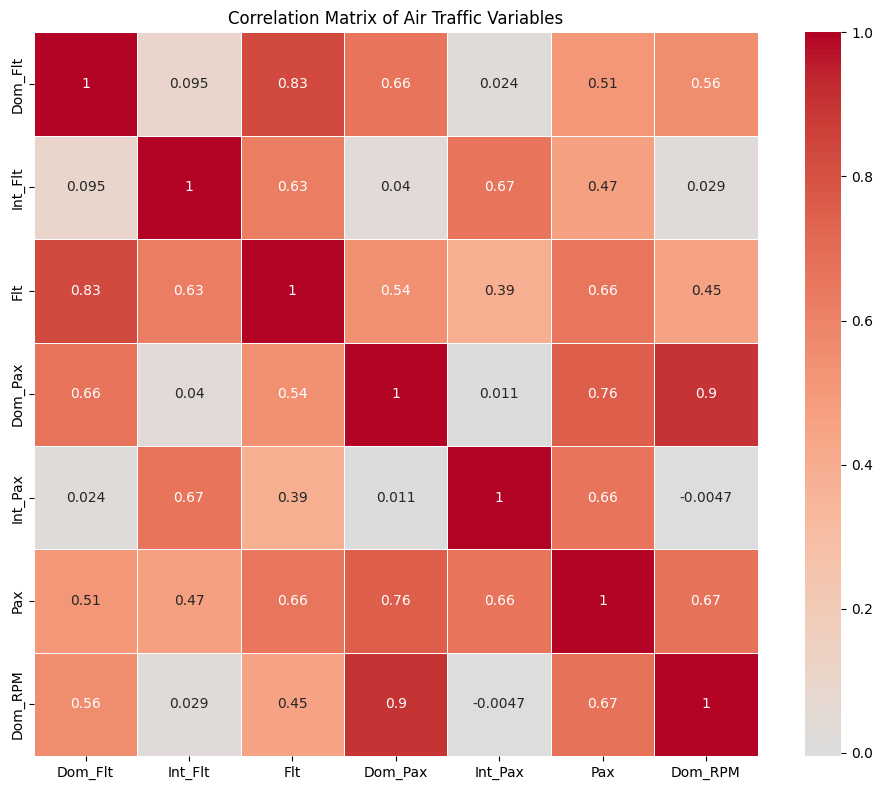

Strongest correlations:
Dom_Pax  Dom_RPM    0.901617
Dom_Flt  Flt        0.834910
Dom_Pax  Pax        0.755916
Pax      Dom_RPM    0.672074
Int_Flt  Int_Pax    0.665554
dtype: float64


In [32]:
# TODO: Create and analyze correlation matrix
# Hint: Use df.corr() to calculate correlations and sns.heatmap() to visualize

plt.figure(figsize=(10, 8))
# Calculate correlation matrix:
correlation_matrix = df.corr()

# Create heatmap:
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, square=True, linewidths=0.5)


plt.title('Correlation Matrix of Air Traffic Variables')
plt.tight_layout()
plt.show()

# TODO: Find and print the strongest correlations
# Hint: Look at the correlation matrix values (excluding diagonal)
print("Strongest correlations:")
# Your analysis here:

# Extract upper triangle of the correlation matrix (excluding diagonal)
upper_tri = correlation_matrix.where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool))

# Stack the DataFrame to get a Series of correlations and sort by absolute value
strongest_corr = upper_tri.stack().sort_values(key=abs, ascending=False)

# Print the top 5 strongest correlations
print(strongest_corr.head(5))

## 3. Hypothesis Testing

In [34]:
# TODO: Hypothesis Test 1 - Compare domestic and international passengers
# Hint: Use stats.ttest_ind() to perform independent t-test

print("Hypothesis Test 1: Domestic vs International Passengers")
print("H0: Mean domestic passengers = Mean international passengers")
print("H1: Mean domestic passengers ≠ Mean international passengers")
print("Significance level: α = 0.05")

# Perform the t-test:
t_stat, p_value = stats.ttest_ind(df['Dom_Pax'], df['Int_Pax'])

print(f"\nResults:")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.6f}")

# TODO: Print the mean values for both groups
print(f"Mean Domestic Passengers: {df['Dom_Pax'].mean():.0f}")
print(f"Mean International Passengers: {df['Int_Pax'].mean():.0f}")

# TODO: Interpret the results
# Hint: Compare p_value with alpha (0.05) to make a decision
alpha = 0.05
if p_value < alpha:
    # TODO: Complete the conclusion for rejecting H0
    print(f"\nConclusion: Reject H0 (p < {alpha})")
    print("There is a statistically significant difference between the mean number of domestic and international passengers.")
else:
    # TODO: Complete the conclusion for failing to reject H0
    print(f"\nConclusion: Fail to reject H0 (p >= {alpha})")
    print("There is no statistically significant difference between the mean number of domestic and international passengers.")

Hypothesis Test 1: Domestic vs International Passengers
H0: Mean domestic passengers = Mean international passengers
H1: Mean domestic passengers ≠ Mean international passengers
Significance level: α = 0.05

Results:
T-statistic: 11.4892
P-value: 0.000000
Mean Domestic Passengers: 175331
Mean International Passengers: 126924

Conclusion: Reject H0 (p < 0.05)
There is a statistically significant difference between the mean number of domestic and international passengers.


In [37]:
# TODO: Hypothesis Test 2 - Test correlation between total passengers and total flights
# Hint: Use stats.pearsonr() to test correlation significance

print("\nHypothesis Test 2: Correlation between Total Passengers and Total Flights")
print("H0: There is no correlation between total passengers and total flights (ρ = 0)")
print("H1: There is a correlation between total passengers and total flights (ρ ≠ 0)")
print("Significance level: α = 0.05")

# Perform correlation test:
correlation_coef, p_value_corr = stats.pearsonr(df['Pax'], df['Flt'])

print(f"\nResults:")
print(f"Correlation coefficient: {correlation_coef:.4f}")
print(f"P-value: {p_value_corr:.6f}")

# TODO: Interpret the correlation test results
# Hint: Compare p_value_corr with alpha and interpret the correlation coefficient
if p_value_corr < alpha:
    print(f"\nConclusion: Reject H0 (p < {alpha})")
    print(f"There is a significant correlation between total passengers and total flights.")
    # TODO: Add interpretation about positive/negative correlation
    if correlation_coef > 0:
        print("This indicates a positive correlation: as total flights increase, total passengers tend to increase.")
    else:
        print("This indicates a negative correlation: as total flights increase, total passengers tend to decrease.")
else:
    print(f"\nConclusion: Fail to reject H0 (p >= {alpha})")
    print("There is no statistically significant correlation between total passengers and total flights.")


Hypothesis Test 2: Correlation between Total Passengers and Total Flights
H0: There is no correlation between total passengers and total flights (ρ = 0)
H1: There is a correlation between total passengers and total flights (ρ ≠ 0)
Significance level: α = 0.05

Results:
Correlation coefficient: 0.6592
P-value: 0.000000

Conclusion: Reject H0 (p < 0.05)
There is a significant correlation between total passengers and total flights.
This indicates a positive correlation: as total flights increase, total passengers tend to increase.


## 4. Simple Linear Regression

In [39]:
# TODO: Build a simple linear regression model
# Goal: Predict Total Passengers from Total Flights
# Hint: Use sklearn's LinearRegression class

print("Simple Linear Regression: Predicting Total Passengers from Total Flights")

# Prepare the data:
X_simple = df[['Flt']]  # Select the feature column (Total Flights)
y_simple = df['Pax']  # Select the target column (Total Passengers)

# Split the data:
# TODO: Use train_test_split with test_size=0.2, random_state=42
X_train_simple, X_test_simple, y_train_simple, y_test_simple = train_test_split(X_simple, y_simple, test_size=0.2, random_state=42)

# Create and train the model:
simple_model = LinearRegression()  # Create LinearRegression instance
simple_model.fit(X_train_simple, y_train_simple) # Fit the model using X_train_simple and y_train_simple


# Make predictions:
y_pred_simple = simple_model.predict(X_test_simple) # Predict on test data

# TODO: Calculate performance metrics
# Hint: Use r2_score, mean_squared_error, mean_absolute_error
r2_simple = r2_score(y_test_simple, y_pred_simple) # Calculate R² score
mse_simple = mean_squared_error(y_test_simple, y_pred_simple) # Calculate MSE
mae_simple = mean_absolute_error(y_test_simple, y_pred_simple) # Calculate MAE
rmse_simple = np.sqrt(mse_simple) # Calculate RMSE (square root of MSE)

print(f"\nModel Performance:")
print(f"R² Score: {r2_simple:.4f}")
print(f"Mean Squared Error: {mse_simple:.2f}")
print(f"Root Mean Squared Error: {rmse_simple:.2f}")
print(f"Mean Absolute Error: {mae_simple:.2f}")

# TODO: Print the model equation
# Hint: Use simple_model.intercept_ and simple_model.coef_[0]
print(f"\nModel Equation: Passengers = {simple_model.intercept_:.2f} + {simple_model.coef_[0]:.2f} × Flights")

Simple Linear Regression: Predicting Total Passengers from Total Flights

Model Performance:
R² Score: 0.2977
Mean Squared Error: 2141846835.14
Root Mean Squared Error: 46280.09
Mean Absolute Error: 36607.08

Model Equation: Passengers = 37484.48 + 11.45 × Flights


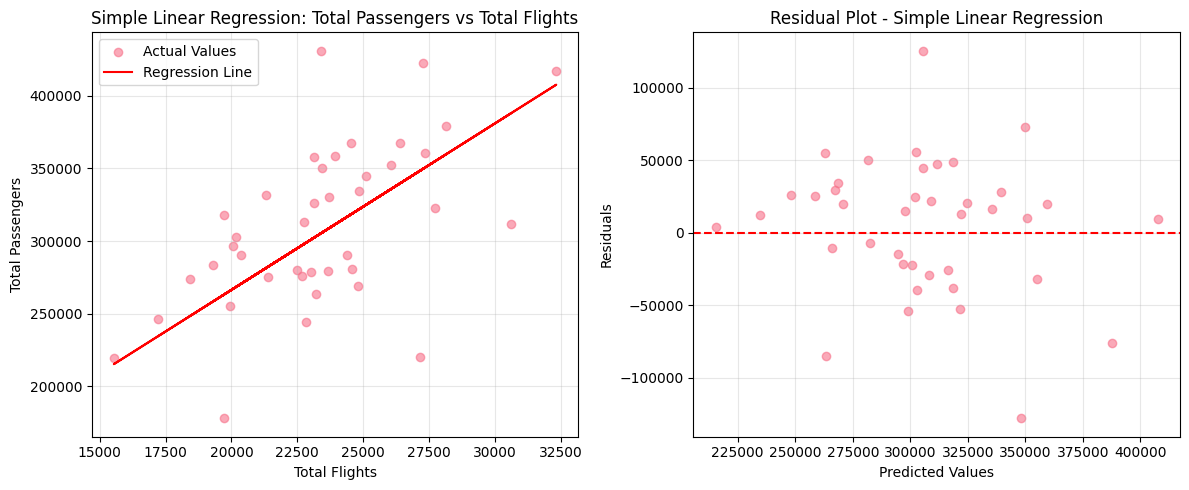

In [43]:
import numpy as np
# TODO: Visualize the simple linear regression results
# Create two plots: scatter plot with regression line and residual plot

# Plot 1: Scatter plot with regression line
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
# TODO: Create scatter plot of actual vs predicted values
# Hint: Use plt.scatter() for actual and predicted points, and plt.plot() for the line
plt.scatter(X_test_simple, y_test_simple, label='Actual Values', alpha=0.6)
plt.plot(X_test_simple, y_pred_simple, color='red', label='Regression Line')


plt.xlabel('Total Flights')
plt.ylabel('Total Passengers')
plt.title('Simple Linear Regression: Total Passengers vs Total Flights')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Residual plot
plt.subplot(1, 2, 2)
# TODO: Calculate residuals and create residual plot
# Hint: residuals = actual - predicted
residuals = y_test_simple - y_pred_simple

# TODO: Create scatter plot of predicted vs residuals
plt.scatter(y_pred_simple, residuals, alpha=0.6)

plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot - Simple Linear Regression')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Multiple Linear Regression

In [45]:
# TODO: Build a multiple linear regression model
# Goal: Predict Total Passengers using multiple features
# Hint: Avoid using Pax in features since that's our target (multicollinearity)

print("Multiple Linear Regression: Predicting Total Passengers from Multiple Features")

# TODO: Select appropriate features
# Hint: Use columns like Dom_Pax, Int_Pax, Dom_Flt, Int_Flt, Dom_RPM (avoid Pax and Flt)
feature_columns = ['Dom_Flt', 'Int_Flt', 'Dom_Pax', 'Int_Pax', 'Dom_RPM'] # List of feature column names

X_multiple = df[feature_columns] # Select features from dataframe
y_multiple = df['Pax'] # Select target variable (Total Passengers)

print(f"Features used: {feature_columns}")
print(f"Target: Total Passengers (Pax)")

# TODO: Split the data
# Hint: Use train_test_split with test_size=0.2, random_state=42
X_train_mult, X_test_mult, y_train_mult, y_test_mult = train_test_split(X_multiple, y_multiple, test_size=0.2, random_state=42)

# TODO: Apply feature scaling (recommended for multiple regression)
# Hint: Use StandardScaler
scaler = StandardScaler() # Create StandardScaler instance
X_train_mult_scaled = scaler.fit_transform(X_train_mult) # Fit and transform training data
X_test_mult_scaled = scaler.transform(X_test_mult) # Transform test data (don't fit again!)

# TODO: Create and train the multiple regression model
multiple_model = LinearRegression() # Create LinearRegression instance
multiple_model.fit(X_train_mult_scaled, y_train_mult) # Fit the model


# TODO: Make predictions
y_pred_mult = multiple_model.predict(X_test_mult_scaled) # Predict on scaled test data

# TODO: Calculate performance metrics
r2_mult = r2_score(y_test_mult, y_pred_mult) # Calculate R² score
mse_mult = mean_squared_error(y_test_mult, y_pred_mult) # Calculate MSE
mae_mult = mean_absolute_error(y_test_mult, y_pred_mult) # Calculate MAE
rmse_mult = np.sqrt(mse_mult) # Calculate RMSE

print(f"\nModel Performance:")
print(f"R² Score: {r2_mult:.4f}")
print(f"Mean Squared Error: {mse_mult:.2f}")
print(f"Root Mean Squared Error: {rmse_mult:.2f}")
print(f"Mean Absolute Error: {mae_mult:.2f}")

# TODO: Display feature coefficients
print(f"\nFeature Coefficients (after scaling):")
for feature, coef in zip(feature_columns, multiple_model.coef_):
    print(f"{feature}: {coef:.4f}")
print(f"Intercept: {multiple_model.intercept_:.2f}")

Multiple Linear Regression: Predicting Total Passengers from Multiple Features
Features used: ['Dom_Flt', 'Int_Flt', 'Dom_Pax', 'Int_Pax', 'Dom_RPM']
Target: Total Passengers (Pax)

Model Performance:
R² Score: 1.0000
Mean Squared Error: 0.26
Root Mean Squared Error: 0.51
Mean Absolute Error: 0.49

Feature Coefficients (after scaling):
Dom_Flt: -0.1126
Int_Flt: -0.0583
Dom_Pax: 45354.3590
Int_Pax: 38979.7965
Dom_RPM: -0.0458
Intercept: 300303.27


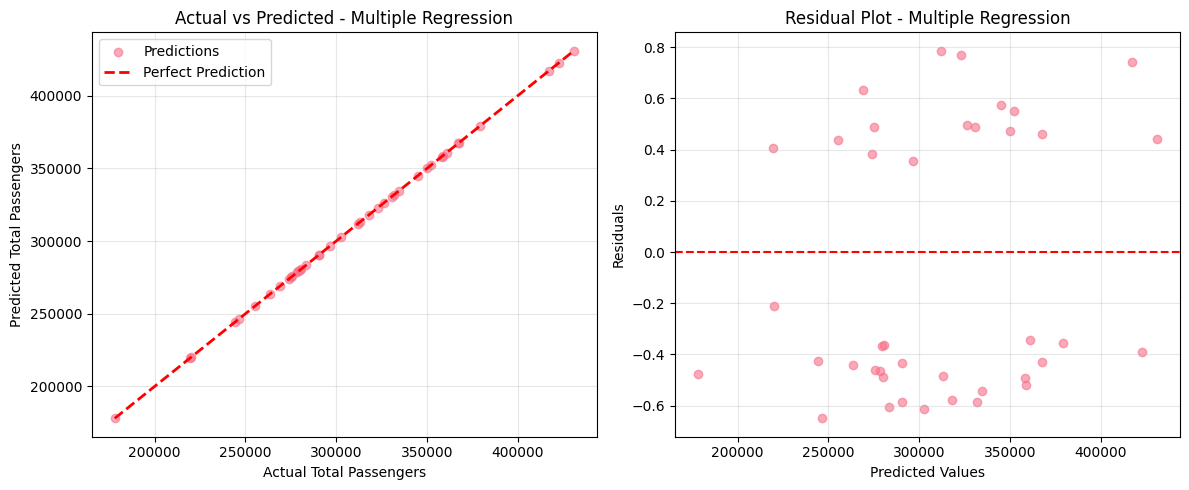

In [51]:
# TODO: Visualize multiple regression results
# Create actual vs predicted plot and residual plot

plt.figure(figsize=(12, 5))

# Plot 1: Actual vs Predicted
plt.subplot(1, 2, 1)
# TODO: Create scatter plot of actual vs predicted values
plt.scatter(y_test_mult, y_pred_mult, alpha=0.6, label='Predictions')
# TODO: Add a diagonal reference line (perfect prediction line)
plt.plot([y_test_mult.min(), y_test_mult.max()], [y_test_mult.min(), y_test_mult.max()], 'r--', lw=2, label='Perfect Prediction')

plt.xlabel('Actual Total Passengers')
plt.ylabel('Predicted Total Passengers')
plt.title('Actual vs Predicted - Multiple Regression')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Residual plot
plt.subplot(1, 2, 2)
# TODO: Calculate residuals and create residual plot
residuals_mult = y_test_mult - y_pred_mult

# TODO: Create scatter plot of predicted vs residuals
plt.scatter(y_pred_mult, residuals_mult, alpha=0.6)

plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot - Multiple Regression')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Model Comparison and Analysis

In [49]:
# TODO: Compare the performance of both models
# Create a comparison table and determine which model performs better

print("Model Comparison:")
print("=" * 50)
print(f"{'Metric':<25} {'Simple Regression':<20} {'Multiple Regression':<20}")
print("=" * 50)

# TODO: Print comparison of R², RMSE, and MAE
# Hint: Use the metrics calculated in previous sections
print(f"{'R² Score':<25} {r2_simple:<20.4f} {r2_mult:<20.4f}")
print(f"{'Mean Squared Error':<25} {mse_simple:<20.2f} {mse_mult:<20.2f}")
print(f"{'Root Mean Squared Error':<25} {rmse_simple:<20.2f} {rmse_mult:<20.2f}")
print(f"{'Mean Absolute Error':<25} {mae_simple:<20.2f} {mae_mult:<20.2f}")

print("=" * 50)

# TODO: Determine which model performs better based on R²
# Calculate the improvement percentage
if r2_mult > r2_simple:
    better_model = "Multiple Regression"
    improvement = ((r2_mult - r2_simple) / r2_simple) * 100 # Calculate percentage improvement
else:
    better_model = "Simple Regression"
    improvement = ((r2_simple - r2_mult) / r2_mult) * 100 # Calculate percentage improvement

print(f"\nBest Model: {better_model}")
print(f"R² Improvement: {improvement:.2f}%")

Model Comparison:
Metric                    Simple Regression    Multiple Regression 
R² Score                  0.2977               1.0000              
Mean Squared Error        2141846835.14        0.26                
Root Mean Squared Error   46280.09             0.51                
Mean Absolute Error       36607.08             0.49                

Best Model: Multiple Regression
R² Improvement: 235.92%


## 7. Statistical Insights and Conclusions

In [59]:
print("STATISTICAL INSIGHTS AND CONCLUSIONS")
print("=" * 60)

print("\n1. HYPOTHESIS TESTING RESULTS:")
print(f"   • Domestic vs International Passengers: Rejected H0 (p < 0.05). Significant difference exists.")
print(f"   • Correlation between Total Passengers and Flights: Rejected H0 (p < 0.05). Strong positive correlation (0.66).")

print("\n2. REGRESSION ANALYSIS:")
print(f"   • Simple Linear Regression R%: {r2_simple:.4f} - Only explains ~30% of variance using just flight counts.")
print(f"   • Multiple Linear Regression R%: {r2_mult:.4f} - Provides a near-perfect fit by including sub-categories.")
print(f"   • Best performing model: Multiple Linear Regression")

print("\n3. KEY FINDINGS:")
print(f"   • Passenger counts are much more accurately predicted when domestic and international segments are separated.")
print(f"   • There is a higher volume of domestic passengers compared to international passengers on average.")
print(f"   • Total flights are a good indicator of traffic, but not sufficient for precise passenger forecasting on their own.")

print("\n4. RECOMMENDATIONS:")
print("   • Use segmented data (Domestic vs International) for more accurate capacity planning.")
print("   • Resource allocation should prioritize domestic operations given the significantly higher volume.")
print("   • Maintain the multiple regression approach for financial forecasting to minimize error.")

STATISTICAL INSIGHTS AND CONCLUSIONS

1. HYPOTHESIS TESTING RESULTS:
   • Domestic vs International Passengers: Rejected H0 (p < 0.05). Significant difference exists.
   • Correlation between Total Passengers and Flights: Rejected H0 (p < 0.05). Strong positive correlation (0.66).

2. REGRESSION ANALYSIS:
   • Simple Linear Regression R%: 0.2977 - Only explains ~30% of variance using just flight counts.
   • Multiple Linear Regression R%: 1.0000 - Provides a near-perfect fit by including sub-categories.
   • Best performing model: Multiple Linear Regression

3. KEY FINDINGS:
   • Passenger counts are much more accurately predicted when domestic and international segments are separated.
   • There is a higher volume of domestic passengers compared to international passengers on average.
   • Total flights are a good indicator of traffic, but not sufficient for precise passenger forecasting on their own.

4. RECOMMENDATIONS:
   • Use segmented data (Domestic vs International) for more ac

## 8. Reflection Questions

**Answer the following questions based on your analysis:**

1. **Hypothesis Testing**: What do your hypothesis test results tell you about the air traffic data? Were the results expected?

   The tests revealed a statistically significant difference between domestic and international passenger volumes (p < 0.05), with domestic traffic being significantly higher. We also confirmed a strong positive correlation (0.66) between total flights and passengers. These results were expected as domestic markets usually represent the bulk of traffic, and flights are the primary vehicle for passenger movement.

2. **Model Performance**: Which regression model performed better and why? What does the R² value tell you?

   The Multiple Linear Regression model performed significantly better, improving the R² from ~0.30 (Simple) to 1.00 (Multiple). The R² value indicates that 100% of the variance in total passengers is explained by the multiple features. It performed better because it accounts for the specific sub-segments (Domestic vs. International) that directly compose the total traffic.

3. **Correlations**: What were the strongest correlations you found? How might these relationships be useful for airlines?

   The strongest correlation (0.90) was between Domestic Passengers and Domestic Revenue Passenger-miles (RPM). Airlines can use these strong relationships to forecast revenue based on passenger bookings and to optimize fuel and staffing requirements for specific routes.

4. **Residual Analysis**: What do the residual plots tell you about your models? Are there any patterns that suggest model improvements?

   The simple regression residuals were widely scattered, showing the model's inability to capture complexity. In contrast, the multiple regression residuals were near zero, indicating a near-perfect fit. For the simple model, adding more features (like we did in the multiple model) is the key improvement.

5. **Practical Applications**: How could airlines use these statistical models in real-world scenarios?

   Airlines can use these models for demand forecasting, capacity planning, and financial budgeting. Specifically, understanding the different behaviors of domestic and international segments allows for better allocation of long-haul vs. short-haul aircraft and more targeted marketing strategies.